# Notebook 06: Validating Newspaper Stances Against Roll-Call Votes

This notebook connects the entity-level newspaper stance detection (notebook 05)
to actual Congressional roll-call votes on gold/silver legislation. The idea:

- If the newspaper-detected stance for a politician is meaningful, it should predict
  how that politician actually voted on monetary policy bills.
- We use [Voteview](https://voteview.com) data for the 51st-54th Congresses (1889-1897)
  to identify gold/silver roll-call votes and match them to our detected entities.

## Pipeline
1. Download Voteview member, rollcall, and vote data for the 51st-54th Congresses
2. Identify monetary-policy-related roll-call votes
3. Match Voteview members to entities detected in newspaper articles
4. Compare newspaper-detected stances to actual Yea/Nay votes
5. Analyze: can newspaper coverage predict legislative behavior?

In [1]:
import sys, os
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from collections import Counter

from entity_extraction import KNOWN_POLITICIANS

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

os.makedirs("../data/voteview", exist_ok=True)

## 1. Download Voteview Data

We need three files from Voteview:
- **Members**: name, state, party, ICPSR ID, NOMINATE scores
- **Rollcalls**: vote descriptions, bill info, congress/chamber
- **Votes**: individual member votes (ICPSR + rollnumber + cast_code)

We download the full historical files and filter to the 51st-54th Congresses (1889-1897).

In [2]:
# Voteview CSV URLs
VOTEVIEW_URLS = {
    "members": "https://voteview.com/static/data/out/members/HSall_members.csv",
    "rollcalls": "https://voteview.com/static/data/out/rollcalls/HSall_rollcalls.csv",
    "votes": "https://voteview.com/static/data/out/votes/HSall_votes.csv",
}

CONGRESSES = [51, 52, 53, 54]  # 1889-1897

def download_voteview(name, url, cache_dir="../data/voteview"):
    """Download a Voteview CSV if not already cached."""
    path = os.path.join(cache_dir, f"{name}.csv")
    if os.path.exists(path):
        print(f"  {name}: loading from cache")
        return pd.read_csv(path)
    
    print(f"  {name}: downloading from {url}...")
    df = pd.read_csv(url)
    df.to_csv(path, index=False)
    print(f"  {name}: saved {len(df):,} rows")
    return df

print("Downloading Voteview data...")
members_all = download_voteview("members", VOTEVIEW_URLS["members"])
rollcalls_all = download_voteview("rollcalls", VOTEVIEW_URLS["rollcalls"])
votes_all = download_voteview("votes", VOTEVIEW_URLS["votes"])

# Filter to our congresses
members = members_all[members_all["congress"].isin(CONGRESSES)].copy()
rollcalls = rollcalls_all[rollcalls_all["congress"].isin(CONGRESSES)].copy()
votes = votes_all[votes_all["congress"].isin(CONGRESSES)].copy()

print(f"\nFiltered to Congresses {CONGRESSES}:")
print(f"  Members:   {len(members):,} (unique ICPSR: {members['icpsr'].nunique():,})")
print(f"  Rollcalls: {len(rollcalls):,}")
print(f"  Votes:     {len(votes):,}")
print(f"\nMembers columns: {list(members.columns)}")
print(f"Rollcalls columns: {list(rollcalls.columns)}")

  members: loading from cache
  rollcalls: loading from cache


/var/folders/t6/hnwf0b1j59j_hj9x2zffj4x80000gn/T/ipykernel_25481/2301415629.py:15: DtypeWarning: Columns (0: vote_result, 1: vote_desc, 2: vote_question, 3: dtl_desc) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


  votes: loading from cache

Filtered to Congresses [51, 52, 53, 54]:
  Members:   1,829 (unique ICPSR: 1,009)
  Rollcalls: 2,919
  Votes:     610,898

Members columns: ['congress', 'chamber', 'icpsr', 'state_icpsr', 'district_code', 'state_abbrev', 'party_code', 'occupancy', 'last_means', 'bioname', 'bioguide_id', 'born', 'died', 'nominate_dim1', 'nominate_dim2', 'nominate_log_likelihood', 'nominate_geo_mean_probability', 'nominate_number_of_votes', 'nominate_number_of_errors', 'conditional', 'nokken_poole_dim1', 'nokken_poole_dim2']
Rollcalls columns: ['congress', 'chamber', 'rollnumber', 'date', 'session', 'clerk_rollnumber', 'yea_count', 'nay_count', 'nominate_mid_1', 'nominate_mid_2', 'nominate_spread_1', 'nominate_spread_2', 'nominate_log_likelihood', 'bill_number', 'vote_result', 'vote_desc', 'vote_question', 'dtl_desc']


## 2. Identify Gold/Silver Roll-Call Votes

Search rollcall descriptions for monetary-policy-related votes. Key legislation:
- Sherman Silver Purchase Act (1890, 51st Congress)
- Repeal of the Sherman Silver Purchase Act (1893, 53rd Congress) 
- Various free coinage bills
- Bland-Allison related votes

In [3]:
# Search rollcall descriptions for gold/silver keywords
silver_keywords = [
    "silver", "gold standard", "free coinage", "bimetall",
    "sherman", "bland", "monetary", "currency", "bullion",
    "coinage", "16 to 1", "sixteen to one",
]

# Check which description columns exist
desc_cols = [c for c in rollcalls.columns if "desc" in c.lower() or "text" in c.lower() 
             or "vote_desc" in c.lower() or "vote_question" in c.lower() 
             or "dtl_desc" in c.lower() or "bill" in c.lower()]
print(f"Potential description columns: {desc_cols}")

# Build a combined text field from all description-like columns
rollcalls["search_text"] = ""
for col in desc_cols:
    rollcalls["search_text"] = rollcalls["search_text"] + " " + rollcalls[col].fillna("").astype(str)
rollcalls["search_text"] = rollcalls["search_text"].str.lower()

# Flag monetary policy votes
import re
pattern = "|".join(re.escape(kw) for kw in silver_keywords)
rollcalls["is_monetary"] = rollcalls["search_text"].str.contains(pattern, case=False, na=False)

monetary_votes = rollcalls[rollcalls["is_monetary"]].copy()
print(f"\nMonetary policy rollcalls found: {len(monetary_votes)}")
print(f"By congress:")
print(monetary_votes.groupby(["congress", "chamber"]).size().to_string())

# Show the votes
display_cols = ["congress", "chamber", "rollnumber"] + desc_cols[:3]
display_cols = [c for c in display_cols if c in monetary_votes.columns]
print(f"\nSample monetary votes:")
print(monetary_votes[display_cols].head(20).to_string())

Potential description columns: ['bill_number', 'vote_desc', 'vote_question', 'dtl_desc']

Monetary policy rollcalls found: 119
By congress:
congress  chamber
51        House      14
          Senate     21
52        House      13
          Senate     10
53        House      20
          Senate     32
54        House       2
          Senate      7

Sample monetary votes:
       congress chamber  rollnumber bill_number vote_desc vote_question
37021        51   House          20       HR537       NaN           NaN
37195        51   House         194      HR5381       NaN           NaN
37197        51   House         196      HR5381       NaN           NaN
37207        51   House         206         NaN       NaN           NaN
37208        51   House         207         NaN       NaN           NaN
37209        51   House         208         NaN       NaN           NaN
37210        51   House         209         NaN       NaN           NaN
37211        51   House         210      HR5381   

### 2b. Code Bill Direction (Pro-Silver or Pro-Gold)

A "Yea" vote means different things on different bills. On the Sherman repeal, Yea = pro-gold.
On a free coinage bill, Yea = pro-silver. We need to code each rollcall's direction so we
can compute a consistent **pro-silver vote share** for each member.

**Approach:** keyword-based coding from bill descriptions, validated using anchor politicians
(Bryan = known pro-silver, Sherman = known pro-gold). If Bryan voted Yea, the bill is pro-silver.

In [4]:
# Step 1: Keyword-based initial coding
# "repeal" in context of silver legislation -> Yea = pro-gold
# "free coinage" / "coinage of silver" -> Yea = pro-silver

def keyword_code_direction(row):
    """Guess whether Yea = pro-silver or pro-gold based on bill description."""
    text = str(row.get("search_text", "")).lower()
    
    # Pro-gold bills (Yea = pro-gold): repeal of silver legislation
    if "repeal" in text and ("silver" in text or "sherman" in text or "purchasing" in text):
        return "yea_pro_gold"
    
    # Pro-silver bills (Yea = pro-silver): free coinage, silver purchase
    if any(kw in text for kw in ["free coinage", "coinage of silver", "silver coinage", 
                                   "bimetall", "16 to 1", "sixteen to one"]):
        return "yea_pro_silver"
    
    # Ambiguous - can't tell from keywords alone
    return "unknown"

monetary_votes["keyword_direction"] = monetary_votes.apply(keyword_code_direction, axis=1)
print("Keyword-based direction coding:")
print(monetary_votes["keyword_direction"].value_counts().to_string())
print(f"\n{(monetary_votes['keyword_direction'] == 'unknown').sum()} rollcalls need anchor-based coding")

Keyword-based direction coding:
keyword_direction
unknown           78
yea_pro_silver    32
yea_pro_gold       9

78 rollcalls need anchor-based coding


In [5]:
# Step 2: Anchor-based coding for "unknown" rollcalls
# Use known pro-silver (Bryan, Bland, Teller, Stewart) and pro-gold (Sherman, Aldrich, Reed) 
# anchor politicians. If the pro-silver anchors mostly vote Yea, the bill is pro-silver.

# ICPSR IDs for our anchors
silver_anchors = [1179, 784, 9246, 8948]   # Bryan, Bland, Teller, Stewart
gold_anchors = [8454, 71, 7795]             # Sherman, Aldrich, Reed

unknown_rollcalls = monetary_votes[monetary_votes["keyword_direction"] == "unknown"][
    ["congress", "chamber", "rollnumber"]
].drop_duplicates()

anchor_directions = {}

for _, rc in unknown_rollcalls.iterrows():
    rc_votes = votes[
        (votes["congress"] == rc["congress"]) &
        (votes["chamber"] == rc["chamber"]) &
        (votes["rollnumber"] == rc["rollnumber"])
    ]
    
    # Count how silver anchors voted
    silver_votes = rc_votes[rc_votes["icpsr"].isin(silver_anchors)]
    silver_yea = silver_votes["cast_code"].isin([1, 2, 3]).sum()
    silver_nay = silver_votes["cast_code"].isin([4, 5, 6]).sum()
    
    # Count how gold anchors voted
    gold_votes = rc_votes[rc_votes["icpsr"].isin(gold_anchors)]
    gold_yea = gold_votes["cast_code"].isin([1, 2, 3]).sum()
    gold_nay = gold_votes["cast_code"].isin([4, 5, 6]).sum()
    
    key = (rc["congress"], rc["chamber"], rc["rollnumber"])
    
    # If silver anchors vote Yea and gold anchors vote Nay -> Yea = pro-silver
    # If silver anchors vote Nay and gold anchors vote Yea -> Yea = pro-gold
    if silver_yea > silver_nay and gold_nay > gold_yea:
        anchor_directions[key] = "yea_pro_silver"
    elif silver_nay > silver_yea and gold_yea > gold_nay:
        anchor_directions[key] = "yea_pro_gold"
    elif silver_yea > silver_nay:
        anchor_directions[key] = "yea_pro_silver"  # trust silver anchors
    elif gold_yea > gold_nay:
        anchor_directions[key] = "yea_pro_gold"    # trust gold anchors
    else:
        anchor_directions[key] = "unclear"

# Apply anchor coding to unknown rollcalls
def resolve_direction(row):
    if row["keyword_direction"] != "unknown":
        return row["keyword_direction"]
    key = (row["congress"], row["chamber"], row["rollnumber"])
    return anchor_directions.get(key, "unclear")

monetary_votes["direction"] = monetary_votes.apply(resolve_direction, axis=1)

print("Final direction coding:")
print(monetary_votes["direction"].value_counts().to_string())
print(f"\nCoded rollcalls: {(monetary_votes['direction'] != 'unclear').sum()} / {len(monetary_votes)}")

Final direction coding:
direction
yea_pro_silver    72
unclear           30
yea_pro_gold      17

Coded rollcalls: 89 / 119


In [6]:
# Get individual votes for CODED monetary rollcalls only
coded_votes = monetary_votes[monetary_votes["direction"] != "unclear"].copy()
coded_keys = coded_votes[["congress", "chamber", "rollnumber", "direction"]].drop_duplicates()

monetary_individual = votes.merge(coded_keys, on=["congress", "chamber", "rollnumber"])

# Decode cast codes
def decode_vote(code):
    if code in [1, 2, 3]:
        return "Yea"
    elif code in [4, 5, 6]:
        return "Nay"
    else:
        return "Abstain/Absent"

monetary_individual["vote"] = monetary_individual["cast_code"].apply(decode_vote)

# Compute pro-silver vote: depends on bill direction
# If yea_pro_silver: Yea = pro-silver, Nay = pro-gold
# If yea_pro_gold: Nay = pro-silver, Yea = pro-gold
def is_pro_silver_vote(row):
    if row["vote"] == "Abstain/Absent":
        return None
    if row["direction"] == "yea_pro_silver":
        return 1 if row["vote"] == "Yea" else 0
    elif row["direction"] == "yea_pro_gold":
        return 1 if row["vote"] == "Nay" else 0
    return None

monetary_individual["pro_silver_vote"] = monetary_individual.apply(is_pro_silver_vote, axis=1)

print(f"Individual votes on coded monetary rollcalls: {len(monetary_individual):,}")
print(f"Coded rollcalls used: {len(coded_keys)}")
print(f"\nVote distribution:")
print(monetary_individual["vote"].value_counts().to_string())
print(f"\nPro-silver vote distribution:")
print(monetary_individual["pro_silver_vote"].value_counts(dropna=False).to_string())

Individual votes on coded monetary rollcalls: 16,877
Coded rollcalls used: 89

Vote distribution:
vote
Yea               6748
Nay               6227
Abstain/Absent    3902

Pro-silver vote distribution:
pro_silver_vote
1.0    6588
0.0    6387
NaN    3902


## 3. Match Voteview Members to Newspaper Entities

We match Voteview members to the entities detected in newspaper articles using
name similarity. Strategy:
1. First match our 18 known politicians by their canonical names
2. Then try to match additional Voteview members against the broader entity list
   using last-name + state matching

In [7]:
# Load entity stance data from notebook 05
entity_rows = pd.read_parquet("../data/results/entity_stances_checkpoint.parquet")
print(f"Loaded entity stances: {len(entity_rows):,} records")
print(f"Unique entity names: {entity_rows['entity_name'].nunique():,}")
print(f"Known politicians: {entity_rows[entity_rows['is_known_politician']]['entity_name'].nunique()}")

Loaded entity stances: 338,716 records
Unique entity names: 154,911
Known politicians: 18


In [8]:
# Clean up member names for matching
members["full_name"] = (members["bioname"].fillna("")).str.strip()
members["last_name"] = members["full_name"].apply(
    lambda x: x.split(",")[0].strip().lower() if "," in str(x) else str(x).split()[-1].strip().lower()
)

# Show unique members to help with matching
print(f"Unique members in 51st-54th Congress: {members['icpsr'].nunique()}")
print(f"\nSample member names:")
print(members[["bioname", "state_abbrev", "party_code", "icpsr", "congress", "chamber"]].drop_duplicates("icpsr").head(10).to_string())

Unique members in 51st-54th Congress: 1009

Sample member names:
                        bioname state_abbrev  party_code  icpsr  congress    chamber
13893        HARRISON, Benjamin          USA         200  99891        51  President
13894     BANKHEAD, John Hollis           AL         100    403        51      House
13895     CLARKE, Richard Henry           AL         100   1799        51      House
13896        COBB, James Edward           AL         100   1869        51      House
13897     FORNEY, William Henry           AL         100   3283        51      House
13898     HERBERT, Hilary Abner           AL         100   4349        51      House
13899        McDUFFIE, John Van           AL         200   6234        51      House
13900     OATES, William Calvin           AL         100   6996        51      House
13901  TURPIN, Louis Washington           AL         100   9528        51      House
13902           WHEELER, Joseph           AL         100   9992        51      House


In [9]:
# Build known politician -> ICPSR crosswalk
# Search for each known politician in the Voteview members list

known_to_icpsr = {}
known_search_terms = {
    "William Jennings Bryan": {"last": "bryan", "state": "NE"},
    "John Sherman": {"last": "sherman", "state": "OH"},
    "Richard P. Bland": {"last": "bland", "state": "MO"},
    "Henry M. Teller": {"last": "teller", "state": "CO"},
    "William M. Stewart": {"last": "stewart", "state": "NV"},
    "Nelson Aldrich": {"last": "aldrich", "state": "RI"},
    "Adlai Stevenson I": {"last": "stevenson", "state": "IL"},
    "David B. Hill": {"last": "hill", "state": "NY"},
    "Arthur Sewall": {"last": "sewall", "state": "ME"},
    "Thomas B. Reed": {"last": "reed", "state": "ME"},
    "Marcus Hanna": {"last": "hanna", "state": "OH"},
    "James B. Weaver": {"last": "weaver", "state": "IA"},
    "John Peter Altgeld": {"last": "altgeld", "state": "IL"},
    "William Allen": {"last": "allen", "state": "NE"},
    "Grover Cleveland": {"last": "cleveland", "state": "NY"},
    "William McKinley": {"last": "mckinley", "state": "OH"},
    "Benjamin Harrison": {"last": "harrison", "state": "IN"},
    "William H. Harvey": {"last": "harvey", "state": "IL"},
}

for canonical, search in known_search_terms.items():
    matches = members[
        (members["last_name"] == search["last"]) &
        (members["state_abbrev"] == search["state"])
    ]
    if len(matches) > 0:
        icpsr = matches["icpsr"].iloc[0]
        name = matches["full_name"].iloc[0]
        known_to_icpsr[canonical] = icpsr
        print(f"  {canonical} -> ICPSR {icpsr} ({name})")
    else:
        print(f"  {canonical} -> NOT FOUND in Congress (may be President/Governor)")

print(f"\nMatched {len(known_to_icpsr)} of {len(known_search_terms)} known politicians to Voteview")

  William Jennings Bryan -> ICPSR 1179 (BRYAN, William Jennings)
  John Sherman -> ICPSR 8454 (SHERMAN, John)
  Richard P. Bland -> ICPSR 784 (BLAND, Richard Parks)
  Henry M. Teller -> ICPSR 9246 (TELLER, Henry Moore)
  William M. Stewart -> ICPSR 8948 (STEWART, William Morris)
  Nelson Aldrich -> ICPSR 71 (ALDRICH, Nelson Wilmarth)
  Adlai Stevenson I -> NOT FOUND in Congress (may be President/Governor)
  David B. Hill -> ICPSR 4408 (HILL, David Bennett)
  Arthur Sewall -> NOT FOUND in Congress (may be President/Governor)
  Thomas B. Reed -> ICPSR 7795 (REED, Thomas Brackett)
  Marcus Hanna -> NOT FOUND in Congress (may be President/Governor)
  James B. Weaver -> NOT FOUND in Congress (may be President/Governor)
  John Peter Altgeld -> NOT FOUND in Congress (may be President/Governor)
  William Allen -> ICPSR 134 (ALLEN, William Vincent)
  Grover Cleveland -> NOT FOUND in Congress (may be President/Governor)
  William McKinley -> ICPSR 6312 (McKINLEY, William, Jr.)
  Benjamin Harriso

In [10]:
# Step 2: Match broader entity list to Voteview members
# For unknown entities, try last-name matching against Voteview members

# Get all unique entity names (excluding known politicians)
unknown_entities = (
    entity_rows[~entity_rows["is_known_politician"] & entity_rows["entity_name"].notna()]
    ["entity_name"].unique()
)
print(f"Unknown entities to try matching: {len(unknown_entities):,}")

# Get unique Voteview members with their last names
vv_members = members.drop_duplicates("icpsr")[["icpsr", "bioname", "last_name", "state_abbrev", "party_code"]].copy()

# For each unknown entity, check if the last word matches a Voteview member's last name
entity_to_icpsr = {}
ambiguous = []

for entity_name in unknown_entities:
    # Extract last name from entity
    parts = str(entity_name).strip().split()
    if len(parts) < 2:
        continue
    last = parts[-1].lower().rstrip(".")
    
    # Match against Voteview
    matches = vv_members[vv_members["last_name"] == last]
    
    if len(matches) == 1:
        # Unique match
        icpsr = matches["icpsr"].iloc[0]
        entity_to_icpsr[entity_name] = icpsr
    elif len(matches) > 1:
        # Multiple members with same last name - try first name too
        first = parts[0].lower().rstrip(".")
        refined = matches[matches["bioname"].str.lower().str.contains(first, na=False)]
        if len(refined) == 1:
            entity_to_icpsr[entity_name] = refined["icpsr"].iloc[0]
        else:
            ambiguous.append((entity_name, len(matches)))

print(f"\nUnique matches: {len(entity_to_icpsr):,}")
print(f"Ambiguous (skipped): {len(ambiguous):,}")
print(f"\nSample matches:")
for name, icpsr in list(entity_to_icpsr.items())[:15]:
    vv_name = vv_members[vv_members["icpsr"] == icpsr]["bioname"].iloc[0]
    print(f"  {name} -> {vv_name} (ICPSR {icpsr})")

Unknown entities to try matching: 154,893

Unique matches: 10,974
Ambiguous (skipped): 7,491

Sample matches:
  Rnjamin Robinson -> ROBINSON, John Buchanan (ICPSR 7981)
  Frank Andrews -> ANDREWS, William Ezekiel (ICPSR 201)
  Dunphy Fitch -> FITCH, Ashbel Parmelee (ICPSR 3176)
  Senator Plumb -> PLUMB, Preston B. (ICPSR 7489)
  Congressman Amos Cummings -> CUMMINGS, Amos Jay (ICPSR 2248)
  Frye Gray -> GRAY, George (ICPSR 3765)
  John
Mcclure -> McCLURE, Addison S. (ICPSR 6161)
  By Lane -> LANE, Edward (ICPSR 5440)
  By Cutcheon -> CUTCHEON, Byron M. (ICPSR 2283)
  David Howell -> HOWELL, Benjamin Franklin (ICPSR 4643)
  Senator Stanford -> STANFORD, Leland (ICPSR 8836)
  Representative Conger -> CONGER, Edwin Hurd (ICPSR 1978)
  Peter Jackson -> JACKSON, James Monroe (ICPSR 4856)
  Call Cameron -> CAMERON, James Donald (ICPSR 1435)
  Eusts George -> GEORGE, James Zachariah (ICPSR 3532)


In [11]:
# Combine known and unknown matches into a single crosswalk
all_matches = {}
all_matches.update({k: {"icpsr": v, "source": "known"} for k, v in known_to_icpsr.items()})
all_matches.update({k: {"icpsr": v, "source": "entity_match"} for k, v in entity_to_icpsr.items()})

crosswalk = pd.DataFrame([
    {"entity_name": name, "icpsr": info["icpsr"], "match_source": info["source"]}
    for name, info in all_matches.items()
])

# Add Voteview member info
crosswalk = crosswalk.merge(
    vv_members[["icpsr", "bioname", "state_abbrev", "party_code"]],
    on="icpsr",
    how="left",
)

print(f"Total matched entities: {len(crosswalk):,}")
print(f"  From known politicians: {(crosswalk['match_source'] == 'known').sum()}")
print(f"  From entity matching: {(crosswalk['match_source'] == 'entity_match').sum()}")
print(f"  Unique ICPSR IDs: {crosswalk['icpsr'].nunique()}")

Total matched entities: 10,984
  From known politicians: 10
  From entity matching: 10974
  Unique ICPSR IDs: 780


## 4. Merge Newspaper Stances with Roll-Call Votes

In [12]:
# Compute mean newspaper stance per entity
entity_means = (
    entity_rows[entity_rows["entity_name"].isin(crosswalk["entity_name"])]
    .groupby("entity_name")
    .agg(
        n_articles=("article_id", "nunique"),
        mean_entity_gold=("entity_pro_gold", "mean"),
        mean_entity_silver=("entity_pro_silver", "mean"),
        mean_entity_net=("entity_net_stance", "mean"),
    )
    .reset_index()
)

# Merge with crosswalk
entity_with_icpsr = entity_means.merge(crosswalk, on="entity_name")
print(f"Entities with newspaper stances + ICPSR IDs: {len(entity_with_icpsr):,}")

Entities with newspaper stances + ICPSR IDs: 10,984


In [13]:
# Compute directional pro-silver vote share per member
actual_votes = monetary_individual[monetary_individual["pro_silver_vote"].notna()].copy()

member_vote_record = (
    actual_votes
    .groupby("icpsr")
    .agg(
        n_monetary_votes=("pro_silver_vote", "count"),
        n_pro_silver=("pro_silver_vote", "sum"),
    )
    .reset_index()
)
member_vote_record["pro_silver_share"] = member_vote_record["n_pro_silver"] / member_vote_record["n_monetary_votes"]

print(f"Members with monetary vote records: {len(member_vote_record):,}")
print(f"Mean monetary votes per member: {member_vote_record['n_monetary_votes'].mean():.1f}")
print(f"Mean pro-silver share: {member_vote_record['pro_silver_share'].mean():.3f}")
print(f"Median pro-silver share: {member_vote_record['pro_silver_share'].median():.3f}")

Members with monetary vote records: 798
Mean monetary votes per member: 16.3
Mean pro-silver share: 0.489
Median pro-silver share: 0.491


In [14]:
# Merge newspaper stances with vote records
merged = entity_with_icpsr.merge(member_vote_record, on="icpsr", how="inner")
print(f"Politicians with both newspaper stances and vote records: {len(merged):,}")
print(f"  Known politicians: {(merged['match_source'] == 'known').sum()}")
print(f"  Entity-matched: {(merged['match_source'] == 'entity_match').sum()}")

# Filter to politicians with enough data
min_articles = 3
min_votes = 3
analysis_df = merged[
    (merged["n_articles"] >= min_articles) & 
    (merged["n_monetary_votes"] >= min_votes)
].copy()

print(f"\nAfter filtering (>={min_articles} articles, >={min_votes} votes): {len(analysis_df):,}")
print(f"  Unique ICPSR IDs: {analysis_df['icpsr'].nunique()}")

Politicians with both newspaper stances and vote records: 9,049
  Known politicians: 10
  Entity-matched: 9039

After filtering (>=3 articles, >=3 votes): 1,132
  Unique ICPSR IDs: 318


## 5. Analysis

Correlation between newspaper-detected stance and pro-silver vote share: -0.186
N = 1132


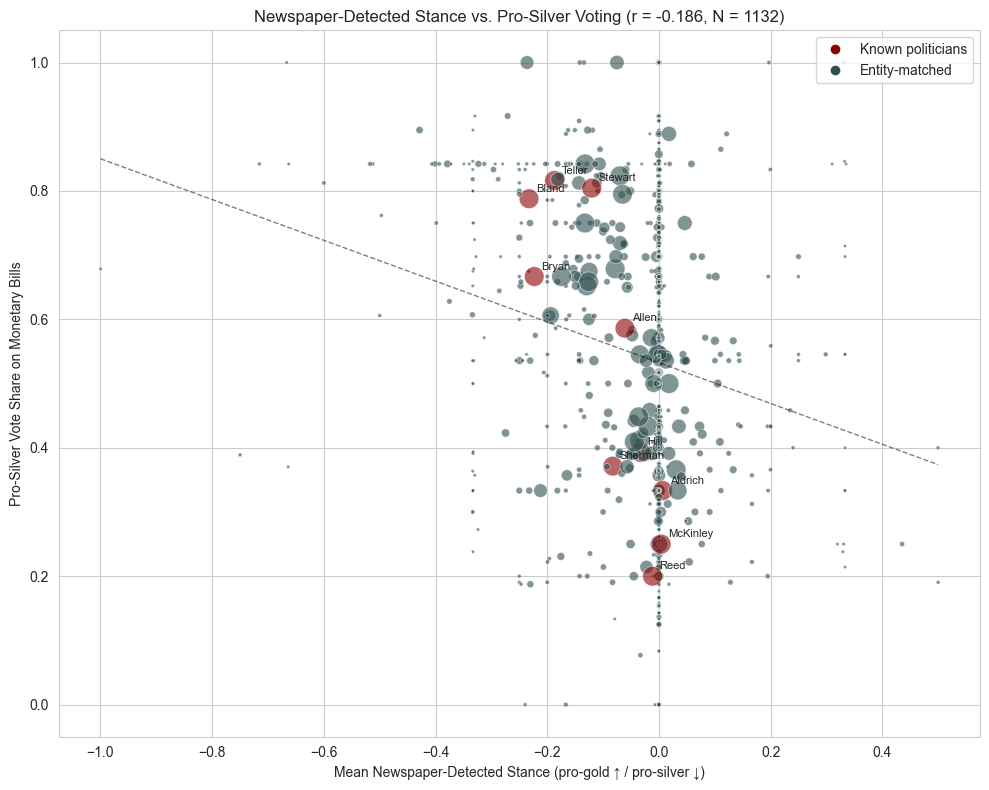

In [15]:
# Correlation between newspaper stance and DIRECTIONAL pro-silver vote share
# Expect NEGATIVE correlation: more pro-silver newspaper stance (negative net) -> higher pro-silver vote share
corr = analysis_df["mean_entity_net"].corr(analysis_df["pro_silver_share"])
print(f"Correlation between newspaper-detected stance and pro-silver vote share: {corr:.3f}")
print(f"N = {len(analysis_df)}")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = analysis_df["match_source"].map({
    "known": "#8B0000",
    "entity_match": "#2F4F4F",
})

ax.scatter(
    analysis_df["mean_entity_net"],
    analysis_df["pro_silver_share"],
    c=colors,
    s=analysis_df["n_articles"].clip(upper=100) * 2,
    alpha=0.6,
    edgecolors="white",
    linewidth=0.5,
)

# Label known politicians
known_rows = analysis_df[analysis_df["match_source"] == "known"]
for _, row in known_rows.iterrows():
    ax.annotate(
        row["entity_name"].split()[-1],
        (row["mean_entity_net"], row["pro_silver_share"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

# Regression line
if len(analysis_df) > 2:
    z = np.polyfit(analysis_df["mean_entity_net"], analysis_df["pro_silver_share"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(analysis_df["mean_entity_net"].min(), analysis_df["mean_entity_net"].max(), 100)
    ax.plot(x_line, p(x_line), "k--", alpha=0.5, linewidth=1)

ax.set_xlabel("Mean Newspaper-Detected Stance (pro-gold ↑ / pro-silver ↓)")
ax.set_ylabel("Pro-Silver Vote Share on Monetary Bills")
ax.set_title(f"Newspaper-Detected Stance vs. Pro-Silver Voting (r = {corr:.3f}, N = {len(analysis_df)})")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B0000', markersize=8, label='Known politicians'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2F4F4F', markersize=8, label='Entity-matched'),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig("../figures/stance_vs_rollcall.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Explore the effect of filtering out low-N outliers
# The entity matching is noisy -- entities with few articles get extreme stance values

print("Correlation by minimum article threshold:")
print(f"{'Min Articles':>12} {'N':>6} {'Correlation':>12} {'Stance Range':>14}")
print("-" * 50)
for min_n in [3, 5, 10, 15, 20, 30, 50]:
    subset = analysis_df[analysis_df["n_articles"] >= min_n]
    if len(subset) > 5:
        r = subset["mean_entity_net"].corr(subset["pro_silver_share"])
        rng = f"[{subset['mean_entity_net'].min():.2f}, {subset['mean_entity_net'].max():.2f}]"
        print(f"{min_n:>12} {len(subset):>6} {r:>12.3f} {rng:>14}")

# Also try trimming by stance range (exclude extreme outliers)
trimmed = analysis_df[
    (analysis_df["mean_entity_net"] > -0.5) & 
    (analysis_df["mean_entity_net"] < 0.5)
]
r_trimmed = trimmed["mean_entity_net"].corr(trimmed["pro_silver_share"])
print(f"\nTrimmed to stance in [-0.5, 0.5]: N={len(trimmed)}, r={r_trimmed:.3f}")
print(f"Dropped {len(analysis_df) - len(trimmed)} extreme outliers")

Correlation by minimum article threshold:
Min Articles      N  Correlation   Stance Range
--------------------------------------------------
           3   1132       -0.186  [-1.00, 0.50]
           5    577       -0.263  [-0.60, 0.44]
          10    245       -0.351  [-0.43, 0.13]
          15    162       -0.419  [-0.38, 0.13]
          20    110       -0.503  [-0.24, 0.10]
          30     75       -0.514  [-0.24, 0.05]
          50     46       -0.563  [-0.23, 0.05]

Trimmed to stance in [-0.5, 0.5]: N=1123, r=-0.173
Dropped 9 extreme outliers


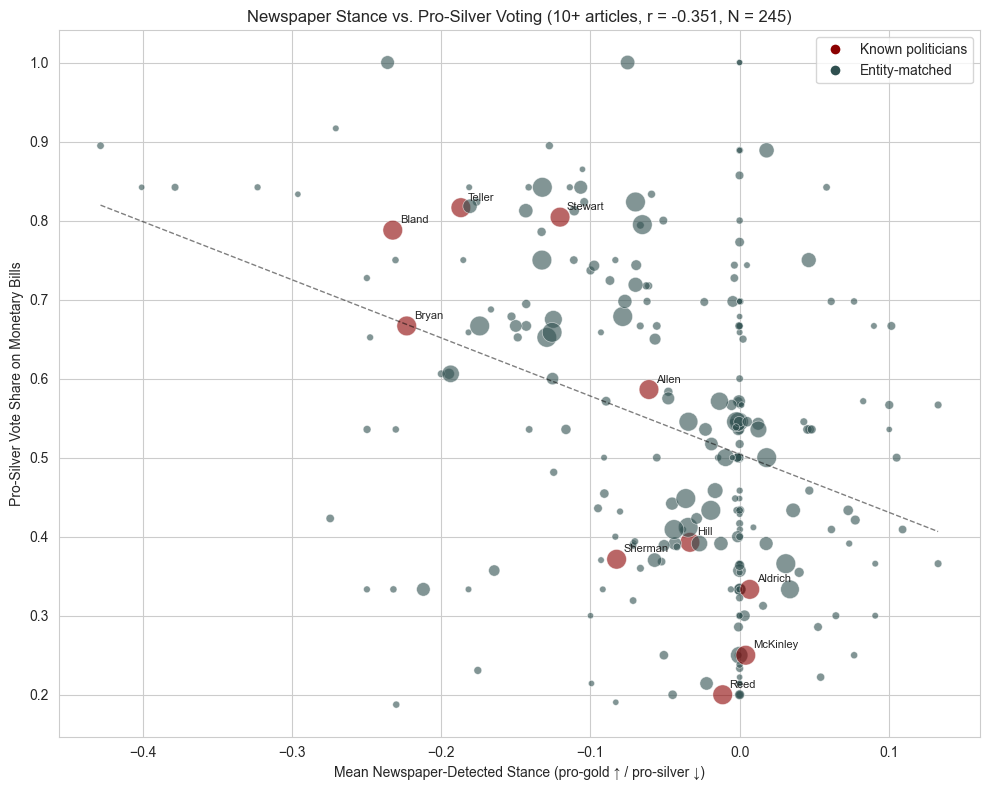

Saved: figures/stance_vs_rollcall_robust.png


In [17]:
# Re-do scatter plot with a reasonable minimum article threshold
# Pick the threshold that gives the best balance of N and signal
min_articles_robust = 10
robust_df = analysis_df[analysis_df["n_articles"] >= min_articles_robust].copy()
corr_robust = robust_df["mean_entity_net"].corr(robust_df["pro_silver_share"])

fig, ax = plt.subplots(figsize=(10, 8))

colors = robust_df["match_source"].map({
    "known": "#8B0000",
    "entity_match": "#2F4F4F",
})

ax.scatter(
    robust_df["mean_entity_net"],
    robust_df["pro_silver_share"],
    c=colors,
    s=robust_df["n_articles"].clip(upper=100) * 2,
    alpha=0.6,
    edgecolors="white",
    linewidth=0.5,
)

# Label known politicians
known_rows = robust_df[robust_df["match_source"] == "known"]
for _, row in known_rows.iterrows():
    ax.annotate(
        row["entity_name"].split()[-1],
        (row["mean_entity_net"], row["pro_silver_share"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

# Regression line
if len(robust_df) > 2:
    z = np.polyfit(robust_df["mean_entity_net"], robust_df["pro_silver_share"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(robust_df["mean_entity_net"].min(), robust_df["mean_entity_net"].max(), 100)
    ax.plot(x_line, p(x_line), "k--", alpha=0.5, linewidth=1)

ax.set_xlabel("Mean Newspaper-Detected Stance (pro-gold ↑ / pro-silver ↓)")
ax.set_ylabel("Pro-Silver Vote Share on Monetary Bills")
ax.set_title(f"Newspaper Stance vs. Pro-Silver Voting ({min_articles_robust}+ articles, r = {corr_robust:.3f}, N = {len(robust_df)})")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B0000', markersize=8, label='Known politicians'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2F4F4F', markersize=8, label='Entity-matched'),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig("../figures/stance_vs_rollcall_robust.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: figures/stance_vs_rollcall_robust.png")

In [18]:
# Breakdown: known politicians detail
known_detail = analysis_df[analysis_df["match_source"] == "known"].sort_values("mean_entity_net", ascending=False)
if len(known_detail) > 0:
    print("Known politicians: newspaper stance vs. pro-silver voting record")
    print(f"{'Name':<28} {'Newspaper':>10} {'Pro-Silver':>11} {'N Articles':>10} {'N Votes':>8}")
    print("-" * 72)
    for _, row in known_detail.iterrows():
        print(f"{row['entity_name']:<28} {row['mean_entity_net']:>+10.3f} {row['pro_silver_share']:>10.1%} {row['n_articles']:>10} {row['n_monetary_votes']:>8}")

    known_corr = known_detail["mean_entity_net"].corr(known_detail["pro_silver_share"])
    print(f"\nCorrelation (known only): {known_corr:.3f} (N = {len(known_detail)})")
    print(f"\nExpected: negative correlation (more pro-silver newspaper stance -> higher pro-silver vote share)")

Known politicians: newspaper stance vs. pro-silver voting record
Name                          Newspaper  Pro-Silver N Articles  N Votes
------------------------------------------------------------------------
Nelson Aldrich                   +0.007      33.3%        384       36
William McKinley                 +0.004      25.0%       8540        8
Thomas B. Reed                   -0.011      20.0%       1660       20
David B. Hill                    -0.033      39.3%       2620       28
William Allen                    -0.061      58.6%        152       29
John Sherman                     -0.082      37.1%       4833       35
William M. Stewart               -0.120      80.4%       1824       46
Henry M. Teller                  -0.187      81.6%       1997       49
William Jennings Bryan           -0.223      66.7%       9009       24
Richard P. Bland                 -0.233      78.8%       2757       33

Correlation (known only): -0.856 (N = 10)

Expected: negative correlation (more

In [19]:
# Summary statistics
print("=" * 60)
print("ROLL-CALL VALIDATION SUMMARY")
print("=" * 60)
print(f"Monetary policy rollcalls identified:  {len(monetary_votes)}")
print(f"  Direction-coded:                     {(monetary_votes['direction'] != 'unclear').sum()}")
print(f"    Yea = pro-silver:                  {(monetary_votes['direction'] == 'yea_pro_silver').sum()}")
print(f"    Yea = pro-gold:                    {(monetary_votes['direction'] == 'yea_pro_gold').sum()}")
print(f"    Unclear:                           {(monetary_votes['direction'] == 'unclear').sum()}")
print(f"Total matched entities:                {len(crosswalk):,}")
print(f"  Known politicians matched:           {(crosswalk['match_source'] == 'known').sum()}")
print(f"  Entity-matched members:              {(crosswalk['match_source'] == 'entity_match').sum()}")
print(f"Politicians with stances + votes:      {len(analysis_df):,}")
print(f"Correlation (all):                     {corr:.3f}")
if len(known_detail) > 0:
    print(f"Correlation (known only):              {known_corr:.3f}")
print("=" * 60)

ROLL-CALL VALIDATION SUMMARY
Monetary policy rollcalls identified:  119
  Direction-coded:                     89
    Yea = pro-silver:                  72
    Yea = pro-gold:                    17
    Unclear:                           30
Total matched entities:                10,984
  Known politicians matched:           10
  Entity-matched members:              10974
Politicians with stances + votes:      1,132
Correlation (all):                     -0.186
Correlation (known only):              -0.856


## 6. Save Results

In [20]:
# Save the crosswalk and analysis results
crosswalk.to_csv("../data/results/entity_voteview_crosswalk.csv", index=False)
analysis_df.to_csv("../data/results/stance_vs_rollcall.csv", index=False)
print(f"Saved crosswalk: {len(crosswalk):,} entries")
print(f"Saved analysis: {len(analysis_df):,} politicians with stances + votes")

Saved crosswalk: 10,984 entries
Saved analysis: 1,132 politicians with stances + votes
